In [1]:
# ====================================================
#  CELL 2 — Imports
# ====================================================
import cv2
import time
import threading
import urllib.request
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.components import containers as mp_containers
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {DEVICE}")
print(f"✓ MediaPipe version: {mp.__version__}")


✓ Using device: cpu
✓ MediaPipe version: 0.10.32


In [3]:
# ====================================================
#  CELL 3 — Download MediaPipe model files (run once)
# ====================================================
import os

def download_model(url, filename):
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, filename)
        print(f"✓ {filename} ready")
    else:
        print(f"✓ {filename} already exists")

download_model(
    "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
    "face_landmarker.task"
)
download_model(
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
    "hand_landmarker.task"
)


✓ face_landmarker.task already exists
✓ hand_landmarker.task already exists


In [5]:
# ====================================================
#  CELL 4 — Config
# ====================================================
GESTURE_CLASSES = ["point", "fist", "open_palm", "thumbs_up", "swipe_left",
                   "swipe_right", "grab", "dismiss", "pinch", "peace"]
NUM_GESTURES = len(GESTURE_CLASSES)
LANDMARK_DIM = 21 * 3   # 21 landmarks × (x, y, z)
SEQ_LEN      = 16
LSTM_HIDDEN  = 128
EYE_SIZE     = 64
FACE_SIZE    = 224

# Face mesh iris indices (same as before)
LEFT_IRIS  = [474, 475, 476, 477]
RIGHT_IRIS = [469, 470, 471, 472]


In [7]:
# ====================================================
#  CELL 5 — Gaze Model
#  Matches gaze_model.pth trained architecture exactly
#  Fusion: 256 + 256 + 512 + 128 = 1152-dim
# ====================================================

EYE_SIZE  = 64
FACE_SIZE = 224

class GazeEstimator(nn.Module):
    def __init__(self, freeze_backbone=True):
        super().__init__()

        def _eye_branch(out=256):
            b = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            if freeze_backbone:
                for p in list(b.parameters())[:-20]:
                    p.requires_grad = False
            b.fc = nn.Linear(b.fc.in_features, out)
            return b

        def _face_branch(out=512):
            b = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            if freeze_backbone:
                for p in list(b.parameters())[:-20]:
                    p.requires_grad = False
            b.fc = nn.Linear(b.fc.in_features, out)
            return b

        self.left_eye_branch  = _eye_branch(256)
        self.right_eye_branch = _eye_branch(256)
        self.face_branch      = _face_branch(512)   # 512-dim ← matches training

        # Head pose: 3 → 128-dim
        self.pose_embed = nn.Sequential(
            nn.Linear(3, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU()
        )

        # Fusion: 256+256+512+128 = 1152 → pitch, yaw
        self.fusion = nn.Sequential(
            nn.Linear(1152, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256),  nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, left_eye, right_eye, face, head_pose):
        return self.fusion(torch.cat([
            self.left_eye_branch(left_eye),
            self.right_eye_branch(right_eye),
            self.face_branch(face),
            self.pose_embed(head_pose)
        ], dim=1))


In [9]:
# ====================================================
#  CELL 6 — Gesture Model
#  Spatial encoder (FC) + Bidirectional LSTM + attention
#  Matches gesture_model.pth trained architecture exactly
# ====================================================

SPATIAL_DIM  = 512
LSTM_HIDDEN  = 256
NUM_GESTURES = 20
LANDMARK_DIM = 21 * 3   # 63
SEQ_LEN      = 32

GESTURE_CLASSES = [
    "point_up", "point_down", "point_left", "point_right",
    "swipe_up", "swipe_down", "swipe_left", "swipe_right",
    "grab", "release", "rotate_cw", "rotate_ccw",
    "zoom_in", "zoom_out", "scroll_up", "scroll_down",
    "wave_dismiss", "two_finger_tap", "palm_hold", "idle"
]

class SpatialEncoder(nn.Module):
    """Per-frame FC encoder: 63 → 512"""
    def __init__(self, input_dim=LANDMARK_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 256),       nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, SPATIAL_DIM)
        )
    def forward(self, x):
        return self.net(x)

class TemporalAttention(nn.Module):
    """Learns to weight informative frames."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (w * x).sum(dim=1)

class GestureRecognizer(nn.Module):
    def __init__(self, num_classes=NUM_GESTURES):
        super().__init__()
        self.spatial_enc = SpatialEncoder()
        self.lstm = nn.LSTM(
            SPATIAL_DIM, LSTM_HIDDEN, num_layers=2,
            batch_first=True, dropout=0.3, bidirectional=True
        )
        self.attention = TemporalAttention(LSTM_HIDDEN * 2)
        self.head = nn.Sequential(
            nn.Linear(LSTM_HIDDEN * 2, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        spatial     = self.spatial_enc(x)       # (batch, seq, 512)
        lstm_out, _ = self.lstm(spatial)         # (batch, seq, 512)
        context     = self.attention(lstm_out)   # (batch, 512)
        return self.head(context)


In [11]:
# ====================================================
#  CELL 7 — Preprocessing helpers + Kalman Filter
# ====================================================

EYE_SIZE  = 64
FACE_SIZE = 224

LEFT_IRIS  = [474, 475, 476, 477]
RIGHT_IRIS = [469, 470, 471, 472]

eye_tf = T.Compose([
    T.ToPILImage(), T.Resize((EYE_SIZE, EYE_SIZE)),
    T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
face_tf = T.Compose([
    T.ToPILImage(), T.Resize((FACE_SIZE, FACE_SIZE)),
    T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def apply_clahe(frame):
    """CLAHE brightness normalization for illumination robustness."""
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def lm_to_px(lm, w, h):
    return int(lm.x * w), int(lm.y * h)

def crop_eye(frame, landmarks, indices, h, w, pad=24):
    pts = [lm_to_px(landmarks[i], w, h) for i in indices]
    xs, ys = zip(*pts)
    x1, y1 = max(0, min(xs)-pad), max(0, min(ys)-pad)
    x2, y2 = min(w, max(xs)+pad), min(h, max(ys)+pad)
    crop = frame[y1:y2, x1:x2]
    return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB) if crop.size else None

def estimate_head_pose(landmarks, h, w):
    model_pts = np.array([
        [0.0,0.0,0.0],[0.0,-330.0,-65.0],
        [-225.0,170.0,-135.0],[225.0,170.0,-135.0],
        [-150.0,-150.0,-125.0],[150.0,-150.0,-125.0]
    ], dtype=np.float64)
    lm_ids  = [1, 152, 33, 263, 61, 291]
    img_pts = np.array(
        [lm_to_px(landmarks[i], w, h) for i in lm_ids],
        dtype=np.float64
    )
    focal   = float(w)
    cam_mtx = np.array([[focal,0,w/2],[0,focal,h/2],[0,0,1]], dtype=np.float64)
    _, rvec, _ = cv2.solvePnP(model_pts, img_pts, cam_mtx, None,
                               flags=cv2.SOLVEPNP_ITERATIVE)
    angles, _ = cv2.Rodrigues(rvec)
    pitch = float(np.arctan2(angles[2,1], angles[2,2]))
    yaw   = float(np.arctan2(-angles[2,0],
                              np.sqrt(angles[2,1]**2 + angles[2,2]**2)))
    roll  = float(np.arctan2(angles[1,0], angles[0,0]))
    return np.array([pitch, yaw, roll], dtype=np.float32)

class KalmanGazeFilter:
    """1D Kalman filter per gaze axis (pitch, yaw)."""
    def __init__(self, process_noise=0.01, measurement_noise=0.1):
        self.Q = process_noise
        self.R = measurement_noise
        self.x = np.zeros(2)
        self.P = np.ones(2)
        self.initialized = False

    def update(self, measurement):
        if not self.initialized:
            self.x = np.array(measurement)
            self.initialized = True
            return self.x.copy()
        self.P += self.Q
        K       = self.P / (self.P + self.R)
        self.x += K * (np.array(measurement) - self.x)
        self.P *= (1 - K)
        return self.x.copy()


In [13]:
# ====================================================
#  CELL 8 — Main Pipeline (Report Spec Aligned)
# ====================================================
class CockpitVisionPipeline:

    def __init__(self):
        # ── PyTorch models ────────────────────────────────────────────
        self.gaze_model    = GazeEstimator().to(DEVICE).eval()
        self.gesture_model = GestureRecognizer().to(DEVICE).eval()
        self.gaze_model.load_state_dict(torch.load("gaze_model.pth", map_location=DEVICE))
        self.gesture_model.load_state_dict(torch.load("gesture_model.pth", map_location=DEVICE))

        # ── MediaPipe Tasks ───────────────────────────────────────────
        self.face_landmarker = mp_vision.FaceLandmarker.create_from_options(
            mp_vision.FaceLandmarkerOptions(
                base_options=mp_python.BaseOptions(model_asset_path="face_landmarker.task"),
                output_face_blendshapes=False,
                output_facial_transformation_matrixes=False,
                num_faces=1
            )
        )
        self.hand_landmarker = mp_vision.HandLandmarker.create_from_options(
            mp_vision.HandLandmarkerOptions(
                base_options=mp_python.BaseOptions(model_asset_path="hand_landmarker.task"),
                num_hands=1
            )
        )

        # ── Kalman filter for gaze smoothing ──────────────────────────
        self.kalman = KalmanGazeFilter(process_noise=0.01, measurement_noise=0.1)

        # ── Sliding windows ───────────────────────────────────────────
        self.landmark_buf   = deque(maxlen=SEQ_LEN)
        self.gesture_voting = deque(maxlen=5)   # majority voting

        # ── Shared state ──────────────────────────────────────────────
        self._gaze_result    = ("N/A", 0.0, 0.0)
        self._gesture_result = ("N/A", 0.0)
        self._lock           = threading.Lock()

        # ── Matplotlib display ────────────────────────────────────────
        self.fig, self.ax = plt.subplots(figsize=(9, 6))
        plt.ion()
        plt.show()

    def _frame_to_mp(self, frame):
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    def _run_gaze(self, frame, face_result):
        h, w = frame.shape[:2]
        lms  = face_result.face_landmarks[0]

        l_crop = crop_eye(frame, lms, LEFT_IRIS,  h, w)
        r_crop = crop_eye(frame, lms, RIGHT_IRIS, h, w)

        xs = [int(lm.x*w) for lm in lms]
        ys = [int(lm.y*h) for lm in lms]
        fx1,fy1 = max(0,min(xs)-20), max(0,min(ys)-20)
        fx2,fy2 = min(w,max(xs)+20), min(h,max(ys)+20)
        f_crop  = cv2.cvtColor(frame[fy1:fy2,fx1:fx2], cv2.COLOR_BGR2RGB)

        if l_crop is None or r_crop is None or f_crop.size == 0:
            return

        pose  = estimate_head_pose(lms, h, w)
        left  = eye_tf(l_crop).unsqueeze(0).to(DEVICE)
        right = eye_tf(r_crop).unsqueeze(0).to(DEVICE)
        face  = face_tf(f_crop).unsqueeze(0).to(DEVICE)
        hp    = torch.tensor(pose).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            out = self.gaze_model(left, right, face, hp)[0]

        # Kalman filter smoothing
        raw      = [float(out[0].detach().cpu().numpy()),
                    float(out[1].detach().cpu().numpy())]
        smoothed = self.kalman.update(raw)
        p_deg    = float(np.degrees(smoothed[0]))
        y_deg    = float(np.degrees(smoothed[1]))

        if   abs(p_deg) < 10 and abs(y_deg) < 15: direction = "FORWARD"
        elif y_deg >  15:                           direction = "LEFT"
        elif y_deg < -15:                           direction = "RIGHT"
        elif p_deg >  10:                           direction = "DOWN"
        else:                                       direction = "UP"

        with self._lock:
            self._gaze_result = (direction, round(p_deg,1), round(y_deg,1))

    def _run_gesture(self, hand_result):
        lms  = hand_result.hand_landmarks[0]
        flat = np.array([[lm.x, lm.y, lm.z] for lm in lms],
                        dtype=np.float32).flatten()
        self.landmark_buf.append(flat)

        if len(self.landmark_buf) < SEQ_LEN:
            return

        seq = torch.tensor(np.stack(self.landmark_buf),
                           dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(self.gesture_model(seq), dim=1)
            conf, idx = probs.max(dim=1)

        # Majority voting over 5-frame window
        self.gesture_voting.append(idx.item())
        voted = max(set(self.gesture_voting), key=self.gesture_voting.count)

        with self._lock:
            self._gesture_result = (GESTURE_CLASSES[voted], round(conf.item(), 2))

    def _draw_hand(self, frame, hand_result):
        h, w = frame.shape[:2]
        lms  = hand_result.hand_landmarks[0]
        connections = [
            (0,1),(1,2),(2,3),(3,4),
            (0,5),(5,6),(6,7),(7,8),
            (0,9),(9,10),(10,11),(11,12),
            (0,13),(13,14),(14,15),(15,16),
            (0,17),(17,18),(18,19),(19,20)
        ]
        pts = [(int(lm.x*w), int(lm.y*h)) for lm in lms]
        for a, b in connections:
            cv2.line(frame, pts[a], pts[b], (0,200,0), 2)
        for pt in pts:
            cv2.circle(frame, pt, 4, (0,255,0), -1)

    def run(self, max_frames=300):
        cap = cv2.VideoCapture(0)
        if not cap.isOpened():
            raise RuntimeError("Camera not accessible.")

        frame_count = 0
        print(f"Running on {DEVICE} — processing {max_frames} frames.")

        while frame_count < max_frames:
            t0  = time.perf_counter()
            ret, frame = cap.read()
            if not ret:
                break

            frame_count += 1
            skip = (frame_count % 2 != 0)

            # CLAHE preprocessing for illumination robustness
            frame = apply_clahe(frame)

            if not skip:
                mp_img      = self._frame_to_mp(frame)
                face_result = self.face_landmarker.detect(mp_img)
                hand_result = self.hand_landmarker.detect(mp_img)

                threads = []
                if face_result.face_landmarks:
                    threads.append(threading.Thread(
                        target=self._run_gaze, args=(frame, face_result)
                    ))
                if hand_result.hand_landmarks:
                    self._draw_hand(frame, hand_result)
                    threads.append(threading.Thread(
                        target=self._run_gesture, args=(hand_result,)
                    ))
                for t in threads: t.start()
                for t in threads: t.join()

            # ── HUD ───────────────────────────────────────────────────
            with self._lock:
                g_dir, g_p, g_y = self._gaze_result
                gest, gest_conf  = self._gesture_result

            latency = int((time.perf_counter() - t0) * 1000)
            hud = [
                f"GAZE:    {g_dir}  (pitch={g_p}, yaw={g_y})",
                f"GESTURE: {gest} ({gest_conf:.0%})",
                f"LATENCY: {latency}ms  [{frame_count}/{max_frames}]"
            ]
            for i, txt in enumerate(hud):
                color = (0,255,0) if latency < 150 else (0,165,255)
                cv2.putText(frame, txt, (10, 30+i*30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.75, color, 2)

            # ── Matplotlib display ────────────────────────────────────
            self.ax.clear()
            self.ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            self.ax.axis('off')
            self.ax.set_title(
                f"GAZE: {g_dir} | GESTURE: {gest} ({gest_conf:.0%}) | {latency}ms",
                fontsize=10, color='green' if latency < 150 else 'orange'
            )
            clear_output(wait=True)
            display(self.fig)
            plt.pause(0.001)

        cap.release()
        print("Stream stopped.")


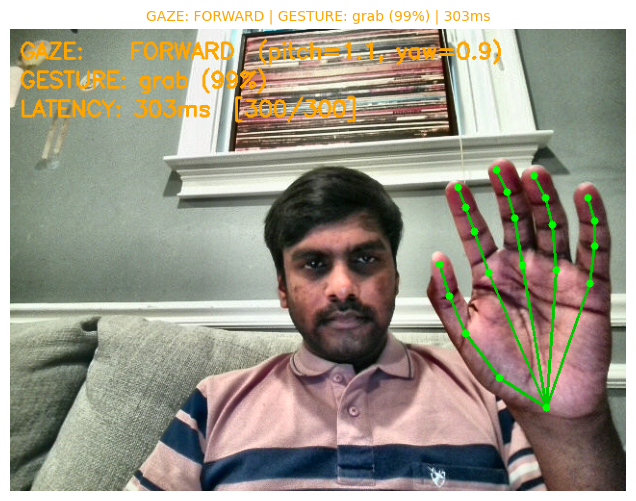

Stream stopped.


In [15]:
# ====================================================
#  CELL 9 — Run
# ====================================================
pipeline = CockpitVisionPipeline()
pipeline.run(max_frames=300)


In [2]:
# Importing Necessary Libraries ─────────────────────────────────────────────────
import os, json
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from collections import deque, Counter
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {DEVICE}")

GESTURE_CLASSES = [
    "point_up", "point_down", "point_left", "point_right",
    "swipe_up", "swipe_down", "swipe_left", "swipe_right",
    "grab", "release", "rotate_cw", "rotate_ccw",
    "zoom_in", "zoom_out", "scroll_up", "scroll_down",
    "wave_dismiss", "two_finger_tap", "palm_hold", "idle"
]
NUM_GESTURES  = len(GESTURE_CLASSES)   # 20
LANDMARK_DIM  = 21 * 3                 # 63
SEQ_LEN       = 32
SPATIAL_DIM   = 512
LSTM_HIDDEN   = 256
BATCH_SIZE    = 32
EPOCHS        = 60
LR            = 5e-4
NUM_SAMPLES_PER_CLASS = 100            # target per gesture


Training on: cpu


In [4]:
# ── CELL T2 — Data Collection ─────────────────────────────────────────
hand_opts = mp_vision.HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path="hand_landmarker.task"),
    num_hands=1
)
hand_landmarker = mp_vision.HandLandmarker.create_from_options(hand_opts)

def collect_gesture_data(append_existing=True):
    """
    Collect gesture sequences from webcam.
    append_existing=True adds to gesture_data.json if it exists.
    Press SPACE to record, Q to skip a gesture class.
    """
    data = {"sequences": [], "labels": []}

    # Load existing data to append
    if append_existing and os.path.exists("gesture_data.json"):
        with open("gesture_data.json", "r") as f:
            data = json.load(f)
        print(f"Loaded {len(data['labels'])} existing sequences")

    for class_idx, gesture_name in enumerate(GESTURE_CLASSES):
        existing = data["labels"].count(class_idx)
        needed   = max(0, NUM_SAMPLES_PER_CLASS - existing)
        if needed == 0:
            print(f"✓ {gesture_name}: already has {existing} samples, skipping")
            continue

        print(f"\n>>> Gesture: '{gesture_name.upper()}'  "
              f"(need {needed} more, have {existing})")
        print("Press SPACE to record | Q to skip")

        cap = cv2.VideoCapture(0)
        cv2.namedWindow("Gesture Collection", cv2.WINDOW_NORMAL)
        cv2.resizeWindow("Gesture Collection", 640, 480)
        cv2.setWindowProperty("Gesture Collection", cv2.WND_PROP_TOPMOST, 1)

        samples_collected = 0
        buf       = deque(maxlen=SEQ_LEN)
        recording = False

        while samples_collected < needed:
            ret, frame = cap.read()
            if not ret:
                break

            rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = hand_landmarker.detect(mp_img)

            status = "RECORDING" if recording else "READY — press SPACE"
            color  = (0,0,255) if recording else (0,255,0)
            cv2.putText(frame, f"Gesture: {gesture_name}", (10,30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
            cv2.putText(frame, status, (10,65),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
            cv2.putText(frame,
                        f"Collected: {samples_collected}/{needed}  "
                        f"(total: {existing+samples_collected})",
                        (10,100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)

            if result.hand_landmarks:
                lms = result.hand_landmarks[0]
                h, w = frame.shape[:2]
                pts  = [(int(lm.x*w), int(lm.y*h)) for lm in lms]
                for pt in pts:
                    cv2.circle(frame, pt, 4, (0,255,0), -1)

                if recording:
                    flat = np.array([[lm.x, lm.y, lm.z] for lm in lms],
                                    dtype=np.float32).flatten()
                    buf.append(flat)
                    if len(buf) == SEQ_LEN:
                        data["sequences"].append(np.stack(buf).tolist())
                        data["labels"].append(class_idx)
                        samples_collected += 1
                        buf.clear()
                        recording = False
                        print(f"  ✓ Sample {existing+samples_collected} captured")

            cv2.imshow("Gesture Collection", frame)
            key = cv2.waitKey(1) & 0xFF
            if key == ord(' '):
                recording = True
                buf.clear()
            elif key == ord('q'):
                print(f"  Skipping {gesture_name}")
                break

        cap.release()
        cv2.destroyAllWindows()

    with open("gesture_data.json", "w") as f:
        json.dump(data, f)
    print(f"\n✓ Saved {len(data['labels'])} total sequences to gesture_data.json")
    return data

# Collect data:
data = collect_gesture_data()


Loaded 0 existing sequences

>>> Gesture: 'POINT_UP'  (need 100 more, have 0)
Press SPACE to record | Q to skip
  ✓ Sample 1 captured
  ✓ Sample 2 captured
  ✓ Sample 3 captured
  ✓ Sample 4 captured
  ✓ Sample 5 captured
  ✓ Sample 6 captured
  ✓ Sample 7 captured
  ✓ Sample 8 captured
  ✓ Sample 9 captured
  ✓ Sample 10 captured
  ✓ Sample 11 captured
  ✓ Sample 12 captured
  ✓ Sample 13 captured
  ✓ Sample 14 captured
  ✓ Sample 15 captured
  ✓ Sample 16 captured
  ✓ Sample 17 captured
  ✓ Sample 18 captured
  ✓ Sample 19 captured
  ✓ Sample 20 captured
  ✓ Sample 21 captured
  ✓ Sample 22 captured
  ✓ Sample 23 captured
  ✓ Sample 24 captured
  ✓ Sample 25 captured
  ✓ Sample 26 captured
  ✓ Sample 27 captured
  ✓ Sample 28 captured
  ✓ Sample 29 captured
  ✓ Sample 30 captured
  ✓ Sample 31 captured
  ✓ Sample 32 captured
  ✓ Sample 33 captured
  ✓ Sample 34 captured
  ✓ Sample 35 captured
  ✓ Sample 36 captured
  ✓ Sample 37 captured
  ✓ Sample 38 captured
  ✓ Sample 39 captured


In [8]:
     # ── CELL T3 — Dataset ─────────────────────────────────────────────────
class GestureDataset(Dataset):
    def __init__(self, sequences, labels):
        self.X = torch.tensor(np.array(sequences), dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


In [10]:
# ── CELL T4 — Model (same architecture as pipeline) ───────────────────
class SpatialEncoder(nn.Module):
    def __init__(self, input_dim=LANDMARK_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 256),       nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, SPATIAL_DIM)
        )
    def forward(self, x): return self.net(x)

class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (w * x).sum(dim=1)

class GestureRecognizer(nn.Module):
    def __init__(self, num_classes=NUM_GESTURES):
        super().__init__()
        self.spatial_enc = SpatialEncoder()
        self.lstm = nn.LSTM(SPATIAL_DIM, LSTM_HIDDEN, num_layers=2,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.attention = TemporalAttention(LSTM_HIDDEN * 2)
        self.head = nn.Sequential(
            nn.Linear(LSTM_HIDDEN*2, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        spatial  = self.spatial_enc(x)
        lstm_out, _ = self.lstm(spatial)
        context  = self.attention(lstm_out)
        return self.head(context)


In [12]:
# ── CELL T5 — Training ────────────────────────────────────────────────
def train_gesture_model():
    with open("gesture_data.json", "r") as f:
        data = json.load(f)

    seqs, labels = data["sequences"], data["labels"]
    print(f"Loaded {len(labels)} sequences | "
          f"Class distribution: {Counter(labels)}")

    X_train, X_val, y_train, y_val = train_test_split(
        seqs, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # Weighted sampler for class imbalance
    class_counts = Counter(y_train)
    weights = [1.0/class_counts[y] for y in y_train]
    sampler = WeightedRandomSampler(weights, len(weights))

    train_loader = DataLoader(GestureDataset(X_train, y_train),
                              batch_size=BATCH_SIZE, sampler=sampler)
    val_loader   = DataLoader(GestureDataset(X_val, y_val),
                              batch_size=BATCH_SIZE)

    model     = GestureRecognizer().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR,
                                 weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    # Weighted cross-entropy (inversely proportional to class frequency)
    total = len(y_train)
    class_w = torch.tensor(
        [total / (NUM_GESTURES * class_counts.get(i, 1))
         for i in range(NUM_GESTURES)],
        dtype=torch.float32
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_w)

    best_val_acc = 0.0

    for epoch in range(1, EPOCHS+1):
        # Train
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for X_b, y_b in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss    += loss.item()
            t_correct += (out.argmax(1) == y_b).sum().item()
            t_total   += y_b.size(0)

        # Validate
        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                v_correct += (model(X_b).argmax(1) == y_b).sum().item()
                v_total   += y_b.size(0)

        t_acc = t_correct / t_total
        v_acc = v_correct / v_total
        scheduler.step(1 - v_acc)

        print(f"Epoch {epoch:02d} | "
              f"Loss: {t_loss/len(train_loader):.4f} | "
              f"Train: {t_acc:.1%} | Val: {v_acc:.1%}")

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), "gesture_model.pth")
            print(f"  ✓ Best model saved (val={v_acc:.1%})")

    print(f"\n✓ Training complete. Best val accuracy: {best_val_acc:.1%}")

train_gesture_model()


Loaded 2000 sequences | Class distribution: Counter({0: 100, 1: 100, 2: 100, 3: 100, 4: 100, 5: 100, 6: 100, 7: 100, 8: 100, 9: 100, 10: 100, 11: 100, 12: 100, 13: 100, 14: 100, 15: 100, 16: 100, 17: 100, 18: 100, 19: 100})


Epoch 1/60: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:29<00:00,  1.68it/s]


Epoch 01 | Loss: 2.7737 | Train: 12.8% | Val: 31.2%
  ✓ Best model saved (val=31.2%)


Epoch 2/60: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:24<00:00,  2.01it/s]


Epoch 02 | Loss: 1.9165 | Train: 37.4% | Val: 54.2%
  ✓ Best model saved (val=54.2%)


...

Epoch 58 | Loss: 0.0146 | Train: 99.6% | Val: 93.5%


Epoch 59/60: 100%|█████████████████████████████████████████████████████████████████████| 50/50 [00:10<00:00,  4.97it/s]


Epoch 59 | Loss: 0.0132 | Train: 99.8% | Val: 93.2%


Epoch 60/60: 100%|█████████████████████████████████████████████████████████████████████| 50/50 [00:09<00:00,  5.29it/s]


Epoch 60 | Loss: 0.0091 | Train: 99.7% | Val: 93.5%

✓ Training complete. Best val accuracy: 94.2%


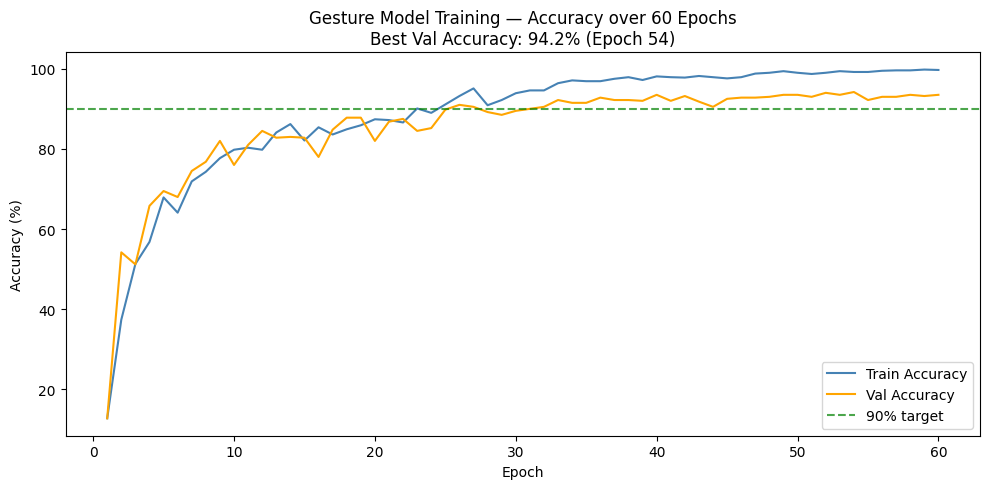

✓ Saved: gesture_training_curve.png


In [1]:
import matplotlib.pyplot as plt

# Paste your training results here
epochs = list(range(1, 61))
val_acc = [
    12.8, 54.2, 51.2, 65.8, 69.5, 68.0, 74.5, 76.8, 82.0, 76.0,
    81.0, 84.5, 82.8, 83.0, 82.8, 78.0, 84.8, 87.8, 87.8, 82.0,
    86.8, 87.5, 84.5, 85.2, 89.8, 91.0, 90.5, 89.2, 88.5, 89.5,
    90.0, 90.5, 92.2, 91.5, 91.5, 92.8, 92.2, 92.2, 92.0, 93.5,
    92.0, 93.2, 91.8, 90.5, 92.5, 92.8, 92.8, 93.0, 93.5, 93.5,
    93.0, 94.0, 93.5, 94.2, 92.2, 93.0, 93.0, 93.5, 93.2, 93.5
]
train_acc = [
    12.8, 37.4, 51.3, 56.8, 67.9, 64.1, 71.9, 74.3, 77.7, 79.8,
    80.3, 79.8, 84.1, 86.2, 82.1, 85.4, 83.6, 84.9, 85.9, 87.4,
    87.2, 86.6, 90.1, 89.0, 91.1, 93.2, 95.1, 90.9, 92.2, 93.9,
    94.6, 94.6, 96.4, 97.1, 96.9, 96.9, 97.5, 97.9, 97.2, 98.1,
    97.9, 97.8, 98.2, 97.9, 97.6, 97.9, 98.8, 99.0, 99.4, 99.0,
    98.7, 99.0, 99.4, 99.2, 99.2, 99.5, 99.6, 99.6, 99.8, 99.7
]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc, label="Train Accuracy", color='steelblue')
plt.plot(epochs, val_acc,   label="Val Accuracy",   color='orange')
plt.axhline(90, color='green', linestyle='--', alpha=0.7, label='90% target')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Gesture Model Training — Accuracy over 60 Epochs\nBest Val Accuracy: 94.2% (Epoch 54)")
plt.legend()
plt.tight_layout()
plt.savefig("gesture_training_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: gesture_training_curve.png")

In [23]:
# ── CELL G1 — Imports ─────────────────────────────────────────────────
import os
import cv2
import json
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {DEVICE}")

EYE_SIZE   = 64
FACE_SIZE  = 224
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 5e-5   # lower LR for fine-tuning unfrozen layers
NPZ_PATH   = "gaze_data.npz"

LEFT_IRIS  = [474, 475, 476, 477]
RIGHT_IRIS = [469, 470, 471, 472]

GAZE_TARGETS = {
    "TL": (-15.0, -20.0), "TC": (-15.0,  0.0), "TR": (-15.0, 20.0),
    "ML": (  0.0, -20.0), "MC": (  0.0,  0.0), "MR": (  0.0, 20.0),
    "BL": ( 15.0, -20.0), "BC": ( 15.0,  0.0), "BR": ( 15.0, 20.0),
}
TARGET_KEYS = list(GAZE_TARGETS.keys())
NUM_SAMPLES_PER_TARGET = 200


Training on: cpu


In [9]:
# ── CELL G2 — Helper functions ────────────────────────────────────────
face_opts = mp_vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path="face_landmarker.task"),
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1
)
face_landmarker = mp_vision.FaceLandmarker.create_from_options(face_opts)

def apply_clahe(frame):
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def lm_to_px(lm, w, h):
    return int(lm.x * w), int(lm.y * h)

def crop_eye_region(frame, landmarks, indices, h, w, pad=24):
    pts = [lm_to_px(landmarks[i], w, h) for i in indices]
    xs, ys = zip(*pts)
    x1,y1 = max(0,min(xs)-pad), max(0,min(ys)-pad)
    x2,y2 = min(w,max(xs)+pad), min(h,max(ys)+pad)
    crop = frame[y1:y2, x1:x2]
    return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB) if crop.size else None

def estimate_head_pose(landmarks, h, w):
    model_pts = np.array([
        [0.0,0.0,0.0],[0.0,-330.0,-65.0],
        [-225.0,170.0,-135.0],[225.0,170.0,-135.0],
        [-150.0,-150.0,-125.0],[150.0,-150.0,-125.0]
    ], dtype=np.float64)
    lm_ids  = [1, 152, 33, 263, 61, 291]
    img_pts = np.array(
        [lm_to_px(landmarks[i], w, h) for i in lm_ids],
        dtype=np.float64
    )
    focal   = float(w)
    cam_mtx = np.array([[focal,0,w/2],[0,focal,h/2],[0,0,1]], dtype=np.float64)
    _, rvec, _ = cv2.solvePnP(model_pts, img_pts, cam_mtx, None,
                               flags=cv2.SOLVEPNP_ITERATIVE)
    angles, _ = cv2.Rodrigues(rvec)
    pitch = float(np.arctan2(angles[2,1], angles[2,2]))
    yaw   = float(np.arctan2(-angles[2,0],
                              np.sqrt(angles[2,1]**2 + angles[2,2]**2)))
    roll  = float(np.arctan2(angles[1,0], angles[0,0]))
    return np.array([pitch, yaw, roll], dtype=np.float32)

def save_npz(left_eyes, right_eyes, faces, poses, labels):
    """Save all arrays to .npz — atomic write prevents corruption."""
    np.savez_compressed(
        NPZ_PATH,
        left_eyes  = np.array(left_eyes,  dtype=np.uint8),
        right_eyes = np.array(right_eyes, dtype=np.uint8),
        faces      = np.array(faces,      dtype=np.uint8),
        poses      = np.array(poses,      dtype=np.float32),
        labels     = np.array(labels,     dtype=np.float32)
    )

def load_npz():
    """Load existing .npz data, return empty lists if not found."""
    if not os.path.exists(NPZ_PATH):
        return [], [], [], [], []
    d = np.load(NPZ_PATH)
    return (d["left_eyes"].tolist(), d["right_eyes"].tolist(),
            d["faces"].tolist(),     d["poses"].tolist(),
            d["labels"].tolist())


In [11]:
# ── CELL G3 — Delete old corrupted JSON (run once) ───────────────────
for f in ["gaze_data.json"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"✓ Deleted corrupted {f}")

# Check existing npz
if os.path.exists(NPZ_PATH):
    d = np.load(NPZ_PATH)
    print(f"✓ Found existing {NPZ_PATH} — {len(d['labels'])} samples")
else:
    print("No existing data found — ready to collect fresh")


✓ Deleted corrupted gaze_data.json
No existing data found — ready to collect fresh


In [13]:
# ── CELL G4 — Data Collection ─────────────────────────────────────────
def collect_gaze_data():
    left_eyes, right_eyes, faces, poses, labels = load_npz()
    existing_count = len(labels)
    print(f"Starting with {existing_count} existing samples")

    for target_key in TARGET_KEYS:
        pitch_deg, yaw_deg = GAZE_TARGETS[target_key]
        target_label = [pitch_deg, yaw_deg]

        existing = sum(1 for l in labels if list(l) == target_label)
        needed   = max(0, NUM_SAMPLES_PER_TARGET - existing)

        if needed == 0:
            print(f"✓ {target_key}: already has {existing} samples")
            continue

        print(f"\n>>> Look at: {target_key}  "
              f"(pitch={pitch_deg}°, yaw={yaw_deg}°) — need {needed} more")
        print("Press SPACE to capture | Q to skip")

        cap = cv2.VideoCapture(0)
        cv2.namedWindow("Gaze Collection", cv2.WINDOW_NORMAL)
        cv2.resizeWindow("Gaze Collection", 640, 480)
        cv2.setWindowProperty("Gaze Collection", cv2.WND_PROP_TOPMOST, 1)

        samples_collected = 0

        while samples_collected < needed:
            ret, frame = cap.read()
            if not ret:
                break

            frame = apply_clahe(frame)
            h, w  = frame.shape[:2]
            rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = face_landmarker.detect(mp_img)

            face_detected = bool(result.face_landmarks)
            cv2.putText(frame, f"Look at: {target_key}", (10,30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,255), 2)
            cv2.putText(frame, f"Captured: {samples_collected}/{needed}",
                        (10,65), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,0), 2)
            cv2.putText(frame,
                        "Face OK — press SPACE" if face_detected else "No face",
                        (10,100), cv2.FONT_HERSHEY_SIMPLEX, 0.75,
                        (0,255,0) if face_detected else (0,0,255), 2)

            cv2.imshow("Gaze Collection", frame)
            key = cv2.waitKey(1) & 0xFF

            if key == ord(' ') and face_detected:
                lms = result.face_landmarks[0]
                l_crop = crop_eye_region(frame, lms, LEFT_IRIS,  h, w)
                r_crop = crop_eye_region(frame, lms, RIGHT_IRIS, h, w)
                xs = [int(lm.x*w) for lm in lms]
                ys = [int(lm.y*h) for lm in lms]
                fx1,fy1 = max(0,min(xs)-20), max(0,min(ys)-20)
                fx2,fy2 = min(w,max(xs)+20), min(h,max(ys)+20)
                f_crop  = frame[fy1:fy2, fx1:fx2]

                if l_crop is None or r_crop is None or f_crop.size == 0:
                    print("  ⚠ Crop failed, try again")
                    continue

                pose = estimate_head_pose(lms, h, w)

                # Resize and store as uint8 numpy arrays (NOT JSON strings)
                left_eyes.append(cv2.resize(l_crop, (EYE_SIZE, EYE_SIZE)))
                right_eyes.append(cv2.resize(r_crop, (EYE_SIZE, EYE_SIZE)))
                faces.append(cv2.resize(
                    cv2.cvtColor(f_crop, cv2.COLOR_BGR2RGB),
                    (FACE_SIZE, FACE_SIZE)
                ))
                poses.append(pose)
                labels.append(target_label)
                samples_collected += 1

                # Save after every 10 samples — prevents data loss on crash
                if samples_collected % 10 == 0:
                    save_npz(left_eyes, right_eyes, faces, poses, labels)
                    print(f"  ✓ {samples_collected}/{needed} — auto-saved")

            elif key == ord('q'):
                print(f"  Skipping {target_key}")
                break

        cap.release()
        cv2.destroyAllWindows()

        # Save after each gesture class completes
        save_npz(left_eyes, right_eyes, faces, poses, labels)
        print(f"✓ {target_key} complete — total: {len(labels)} samples saved")

    print(f"\n✓ Collection complete: {len(labels)} total samples in {NPZ_PATH}")
    return left_eyes, right_eyes, faces, poses, labels

left_eyes, right_eyes, faces, poses, labels = collect_gaze_data()


Starting with 0 existing samples

>>> Look at: TL  (pitch=-15.0°, yaw=-20.0°) — need 200 more
Press SPACE to capture | Q to skip
  ✓ 10/200 — auto-saved
  ✓ 20/200 — auto-saved
  ✓ 30/200 — auto-saved
  ✓ 40/200 — auto-saved
  ✓ 50/200 — auto-saved
  ✓ 60/200 — auto-saved
  ✓ 70/200 — auto-saved
  ✓ 80/200 — auto-saved
  ✓ 90/200 — auto-saved
  ✓ 100/200 — auto-saved
  ✓ 110/200 — auto-saved
  ✓ 120/200 — auto-saved
  ✓ 130/200 — auto-saved
  ✓ 140/200 — auto-saved
  ✓ 150/200 — auto-saved
  ✓ 160/200 — auto-saved
  ✓ 170/200 — auto-saved
  ✓ 180/200 — auto-saved
  ✓ 190/200 — auto-saved
  ✓ 200/200 — auto-saved
✓ TL complete — total: 200 samples saved

>>> Look at: TC  (pitch=-15.0°, yaw=0.0°) — need 200 more
Press SPACE to capture | Q to skip
  ✓ 10/200 — auto-saved
  ✓ 20/200 — auto-saved
  ✓ 30/200 — auto-saved
  ✓ 40/200 — auto-saved
  ✓ 50/200 — auto-saved
  ✓ 60/200 — auto-saved
  ✓ 70/200 — auto-saved
  ✓ 80/200 — auto-saved
  ✓ 90/200 — auto-saved
  ✓ 100/200 — auto-saved
  ✓ 

In [15]:
# ── CELL G5 — Dataset ─────────────────────────────────────────────────
eye_tf = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
face_tf = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class GazeDataset(Dataset):
    def __init__(self, left_eyes, right_eyes, faces, poses, labels):
        self.left_eyes  = np.array(left_eyes,  dtype=np.uint8)
        self.right_eyes = np.array(right_eyes, dtype=np.uint8)
        self.faces      = np.array(faces,      dtype=np.uint8)
        self.poses      = torch.tensor(np.array(poses),  dtype=torch.float32)
        self.labels     = torch.tensor(
            np.radians(np.array(labels, dtype=np.float32)),
            dtype=torch.float32
        )

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        return (eye_tf(self.left_eyes[i]),
                eye_tf(self.right_eyes[i]),
                face_tf(self.faces[i]),
                self.poses[i],
                self.labels[i])
                                                                        

In [25]:
# ── CELL G6 — Model ───────────────────────────────────────────────────
class GazeEstimator(nn.Module):
    def __init__(self, freeze_backbone=True):
        super().__init__()

        def _eye_branch(out=256):
            b = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            if freeze_backbone:
                for p in list(b.parameters())[:-20]:  # unfreeze more layers
                    p.requires_grad = False
            b.fc = nn.Linear(b.fc.in_features, out)
            return b

        def _face_branch(out=512):
            b = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            if freeze_backbone:
                for p in list(b.parameters())[:-20]:  # unfreeze more layers
                    p.requires_grad = False
            b.fc = nn.Linear(b.fc.in_features, out)
            return b

        self.left_eye_branch  = _eye_branch(256)
        self.right_eye_branch = _eye_branch(256)
        self.face_branch      = _face_branch(512)
        self.pose_embed = nn.Sequential(
            nn.Linear(3, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU()
        )
        self.fusion = nn.Sequential(
            nn.Linear(1152, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256),  nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, left_eye, right_eye, face, head_pose):
        return self.fusion(torch.cat([
            self.left_eye_branch(left_eye),
            self.right_eye_branch(right_eye),
            self.face_branch(face),
            self.pose_embed(head_pose)
        ], dim=1))


In [19]:
# ── CELL G7 — Loss ────────────────────────────────────────────────────
class GazeLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.mse   = nn.MSELoss()

    def forward(self, pred, target):
        mse_loss     = self.mse(pred, target)
        pred_n       = nn.functional.normalize(pred,   dim=1)
        target_n     = nn.functional.normalize(target, dim=1)
        cos_sim      = (pred_n * target_n).sum(dim=1).clamp(-1+1e-7, 1-1e-7)
        angular_loss = torch.acos(cos_sim).mean()
        return mse_loss + self.alpha * angular_loss


Loaded 1800 samples | File size: 271.1 MB
✓ Loaded checkpoint — continuing fine-tuning from saved weights


Epoch 1/50: 100%|██████████████████████████████████████████████████████████████████████| 45/45 [01:14<00:00,  1.65s/it]


Epoch 01 | Loss: 0.1071 | Val: 0.0872 | Angular Error: 9.69°
  ✓ Saved (val=0.0872, err=9.69°)


Epoch 2/50: 100%|██████████████████████████████████████████████████████████████████████| 45/45 [01:17<00:00,  1.71s/it]


Epoch 02 | Loss: 0.1067 | Val: 0.0881 | Angular Error: 9.77°


...

Epoch 48 | Loss: 0.0961 | Val: 0.0768 | Angular Error: 8.70°
  ✓ Saved (val=0.0768, err=8.70°)


Epoch 49/50: 100%|█████████████████████████████████████████████████████████████████████| 45/45 [03:23<00:00,  4.53s/it]


Epoch 49 | Loss: 0.0963 | Val: 0.0771 | Angular Error: 8.73°


Epoch 50/50: 100%|█████████████████████████████████████████████████████████████████████| 45/45 [05:10<00:00,  6.89s/it]


Epoch 50 | Loss: 0.0958 | Val: 0.0777 | Angular Error: 8.81°


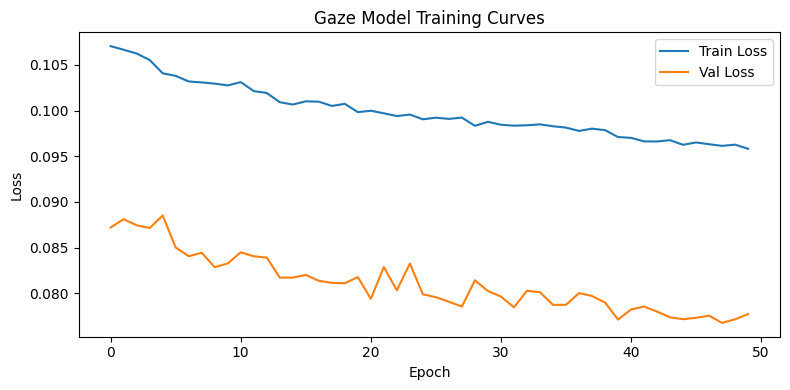


✓ Done. Best val loss: 0.0768


In [27]:
# ── CELL G8 — Training ────────────────────────────────────────────────
def train_gaze_model():
    # Load from npz
    d = np.load(NPZ_PATH)
    le, re, fa = d["left_eyes"], d["right_eyes"], d["faces"]
    po, lb     = d["poses"],     d["labels"]

    n = len(lb)
    print(f"Loaded {n} samples | File size: "
          f"{os.path.getsize(NPZ_PATH)/1e6:.1f} MB")

    idx = list(range(n))
    tr_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42)

    def subset(idxs):
        return (le[idxs], re[idxs], fa[idxs], po[idxs], lb[idxs])

    tr_idx  = np.array(tr_idx)
    val_idx = np.array(val_idx)

    train_loader = DataLoader(GazeDataset(*subset(tr_idx)),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(GazeDataset(*subset(val_idx)),
                              batch_size=BATCH_SIZE)

    model     = GazeEstimator().to(DEVICE)
    # Load checkpoint — continue from 9.35°
    if os.path.exists("gaze_model.pth"):
        model.load_state_dict(torch.load("gaze_model.pth", map_location=DEVICE))
        print("✓ Loaded checkpoint — continuing fine-tuning from saved weights")
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    criterion     = GazeLoss(alpha=0.5)
    best_val_loss = float("inf")
    train_losses, val_losses = [], []

    for epoch in range(1, EPOCHS+1):
        model.train()
        t_loss = 0.0
        for l, r, f, p, y in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
            l,r,f,p,y = l.to(DEVICE),r.to(DEVICE),f.to(DEVICE),\
                        p.to(DEVICE),y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(l,r,f,p), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss, v_angle = 0.0, 0.0
        with torch.no_grad():
            for l, r, f, p, y in val_loader:
                l,r,f,p,y = l.to(DEVICE),r.to(DEVICE),f.to(DEVICE),\
                            p.to(DEVICE),y.to(DEVICE)
                out     = model(l,r,f,p)
                v_loss += criterion(out, y).item()
                pred_n  = nn.functional.normalize(out, dim=1)
                gt_n    = nn.functional.normalize(y,   dim=1)
                cos_sim = (pred_n * gt_n).sum(dim=1).clamp(-1+1e-7, 1-1e-7)
                v_angle += torch.acos(cos_sim).mean().item()

        t_loss      /= len(train_loader)
        v_loss      /= len(val_loader)
        v_angle_deg  = np.degrees(v_angle / len(val_loader))
        scheduler.step(v_loss)
        train_losses.append(t_loss)
        val_losses.append(v_loss)

        print(f"Epoch {epoch:02d} | Loss: {t_loss:.4f} | "
              f"Val: {v_loss:.4f} | Angular Error: {v_angle_deg:.2f}°")

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), "gaze_model.pth")
            print(f"  ✓ Saved (val={v_loss:.4f}, err={v_angle_deg:.2f}°)")

    plt.figure(figsize=(8,4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses,   label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Gaze Model Training Curves")
    plt.legend(); plt.tight_layout(); plt.show()

    print(f"\n✓ Done. Best val loss: {best_val_loss:.4f}")

train_gaze_model()


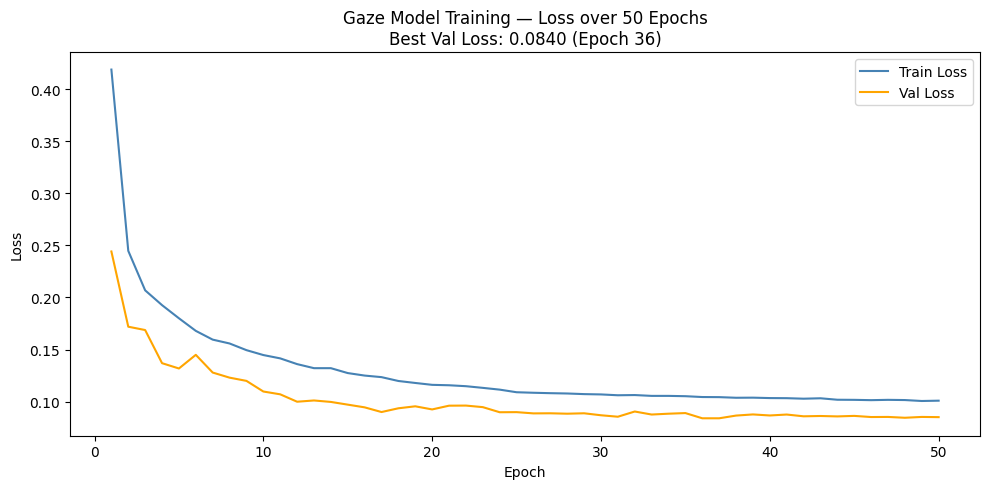

✓ Saved: gaze_training_curve.png


In [3]:
import matplotlib.pyplot as plt

epochs = list(range(1, 51))
train_loss = [
    0.4187, 0.2447, 0.2068, 0.1926, 0.1800, 0.1679, 0.1595, 0.1558,
    0.1494, 0.1447, 0.1415, 0.1360, 0.1321, 0.1321, 0.1274, 0.1250,
    0.1235, 0.1198, 0.1179, 0.1161, 0.1157, 0.1148, 0.1132, 0.1115,
    0.1090, 0.1085, 0.1081, 0.1078, 0.1072, 0.1069, 0.1061, 0.1063,
    0.1055, 0.1055, 0.1052, 0.1044, 0.1043, 0.1037, 0.1038, 0.1034,
    0.1033, 0.1028, 0.1032, 0.1018, 0.1017, 0.1014, 0.1017, 0.1015,
    0.1006, 0.1009
]
val_loss = [
    0.2441, 0.1719, 0.1687, 0.1369, 0.1318, 0.1449, 0.1279, 0.1230,
    0.1199, 0.1097, 0.1070, 0.0999, 0.1011, 0.0997, 0.0971, 0.0945,
    0.0900, 0.0936, 0.0955, 0.0925, 0.0961, 0.0962, 0.0947, 0.0898,
    0.0899, 0.0887, 0.0888, 0.0884, 0.0888, 0.0869, 0.0855, 0.0905,
    0.0876, 0.0884, 0.0890, 0.0840, 0.0840, 0.0866, 0.0877, 0.0867,
    0.0876, 0.0859, 0.0862, 0.0858, 0.0863, 0.0852, 0.0853, 0.0845,
    0.0853, 0.0851
]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label="Train Loss", color='steelblue')
plt.plot(epochs, val_loss,   label="Val Loss",   color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gaze Model Training — Loss over 50 Epochs\nBest Val Loss: 0.0840 (Epoch 36)")
plt.legend()
plt.tight_layout()
plt.savefig("gaze_training_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: gaze_training_curve.png")

In [22]:
# ── CELL E1 — Imports ─────────────────────────────────────────────────
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import deque, Counter
import time
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating on: {DEVICE}")

GESTURE_CLASSES = [
    "point_up", "point_down", "point_left", "point_right",
    "swipe_up", "swipe_down", "swipe_left", "swipe_right",
    "grab", "release", "rotate_cw", "rotate_ccw",
    "zoom_in", "zoom_out", "scroll_up", "scroll_down",
    "wave_dismiss", "two_finger_tap", "palm_hold", "idle"
]
GAZE_REGIONS = {
    "TL": (-15.0, -20.0), "TC": (-15.0,  0.0), "TR": (-15.0, 20.0),
    "ML": (  0.0, -20.0), "MC": (  0.0,  0.0), "MR": (  0.0, 20.0),
    "BL": ( 15.0, -20.0), "BC": ( 15.0,  0.0), "BR": ( 15.0, 20.0),
}
GAZE_DIRECTION_MAP = {
    "TL": "UP",   "TC": "UP",   "TR": "UP",
    "ML": "LEFT", "MC": "FORWARD", "MR": "RIGHT",
    "BL": "DOWN", "BC": "DOWN", "BR": "DOWN"
}
NUM_GESTURES  = 20
LANDMARK_DIM  = 63
SEQ_LEN       = 32
SPATIAL_DIM   = 512
LSTM_HIDDEN   = 256
EYE_SIZE      = 64
FACE_SIZE     = 224
NPZ_PATH      = "gaze_data.npz"
BATCH_SIZE    = 32


Evaluating on: cpu


In [26]:
# ── CELL E2 — Model Definitions (must match trained architectures) ─────
class SpatialEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LANDMARK_DIM, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 256),          nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, SPATIAL_DIM)
        )
    def forward(self, x): return self.net(x)

class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (w * x).sum(dim=1)

class GestureRecognizer(nn.Module):
    def __init__(self):
        super().__init__()
        self.spatial_enc = SpatialEncoder()
        self.lstm = nn.LSTM(SPATIAL_DIM, LSTM_HIDDEN, num_layers=2,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.attention = TemporalAttention(LSTM_HIDDEN * 2)
        self.head = nn.Sequential(
            nn.Linear(LSTM_HIDDEN*2, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, NUM_GESTURES)
        )
    def forward(self, x):
        s = self.spatial_enc(x)
        o, _ = self.lstm(s)
        return self.head(self.attention(o))

class GazeEstimator(nn.Module):
    def __init__(self):
        super().__init__()
        def _eye(out=256):
            b = models.resnet18(weights=None)
            b.fc = nn.Linear(b.fc.in_features, out)
            return b
        def _face(out=512):
            b = models.resnet18(weights=None)
            b.fc = nn.Linear(b.fc.in_features, out)
            return b
        self.left_eye_branch  = _eye()
        self.right_eye_branch = _eye()
        self.face_branch      = _face()
        self.pose_embed = nn.Sequential(
            nn.Linear(3,64), nn.ReLU(), nn.Linear(64,128), nn.ReLU()
        )
        self.fusion = nn.Sequential(
            nn.Linear(1152,512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512,256),  nn.ReLU(), nn.Linear(256,2)
        )
    def forward(self, l, r, f, p):
        return self.fusion(torch.cat([
            self.left_eye_branch(l), self.right_eye_branch(r),
            self.face_branch(f),     self.pose_embed(p)
        ], dim=1))


In [28]:
# ── CELL E3 — Load Models ─────────────────────────────────────────────
gesture_model = GestureRecognizer().to(DEVICE)
gesture_model.load_state_dict(torch.load("gesture_model.pth", map_location=DEVICE))
gesture_model.eval()
print("✓ Gesture model loaded")

gaze_model = GazeEstimator().to(DEVICE)
gaze_model.load_state_dict(torch.load("gaze_model.pth", map_location=DEVICE))
gaze_model.eval()
print("✓ Gaze model loaded")


✓ Gesture model loaded
✓ Gaze model loaded



GESTURE MODEL EVALUATION

Overall Accuracy:     94.2%
Mean Confidence:      98.3%
Mean Inference Time:  3.83ms per sample

Gesture               Precision     Recall         F1
----------------------------------------------------
point_up                  94.1%      80.0%      86.5%
point_down                95.0%      95.0%      95.0%
point_left                81.8%      90.0%      85.7%
point_right              100.0%     100.0%     100.0%
swipe_up                 100.0%      90.0%      94.7%
swipe_down                90.5%      95.0%      92.7%
swipe_left               100.0%      95.0%      97.4%
swipe_right              100.0%      90.0%      94.7%
grab                      81.8%      90.0%      85.7%
release                   86.4%      95.0%      90.5%
rotate_cw                 90.5%      95.0%      92.7%
rotate_ccw               100.0%      90.0%      94.7%
zoom_in                   90.0%      90.0%      90.0%
zoom_out                 100.0%     100.0%     100.0%
scroll_up    

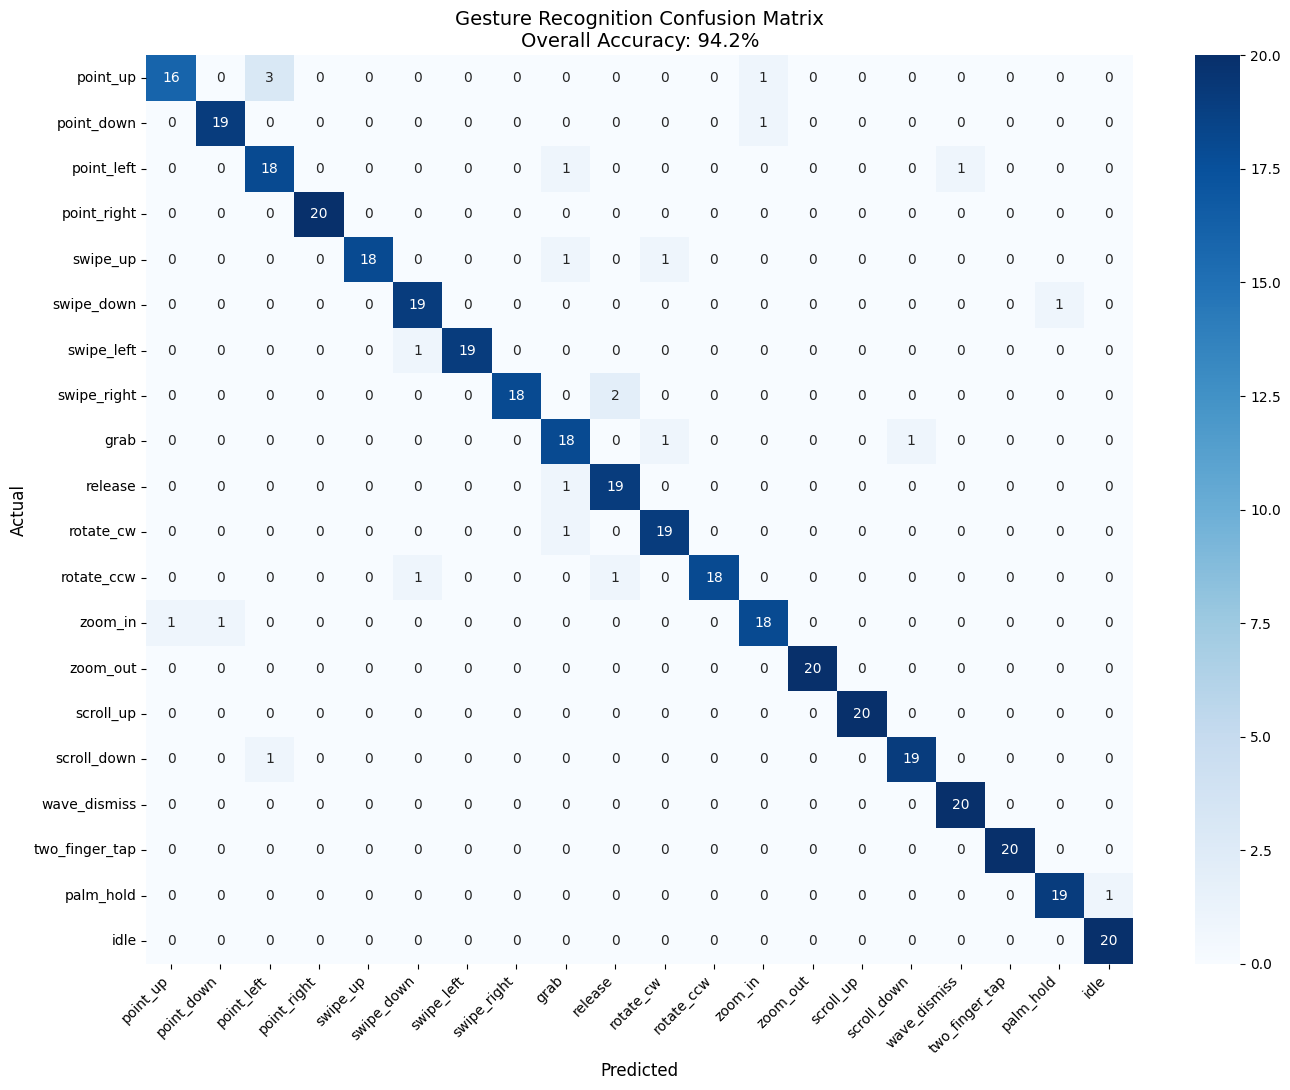

✓ Saved: gesture_confusion_matrix.png


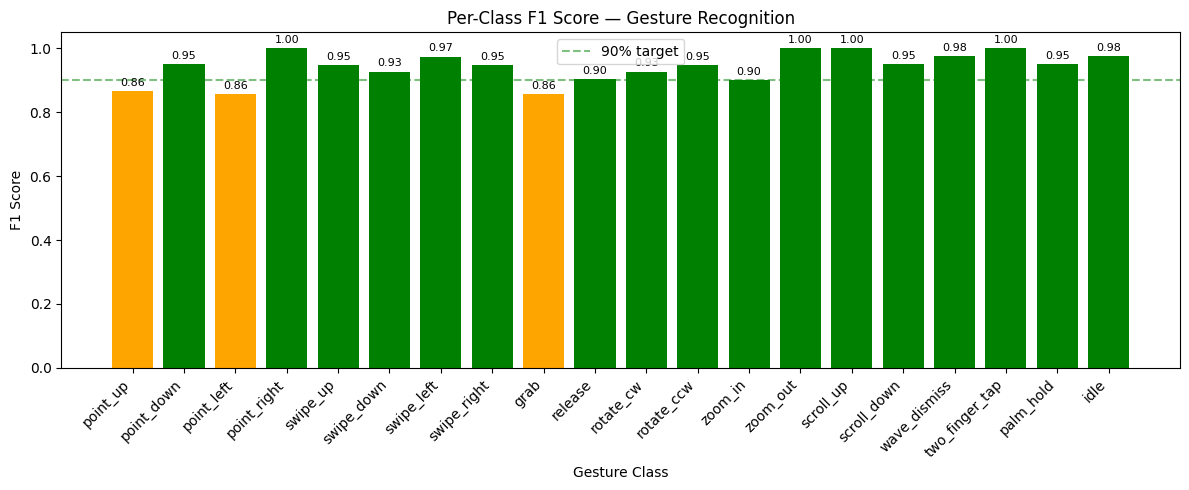

✓ Saved: gesture_f1_scores.png


In [40]:
# ── CELL E4 — Gesture Evaluation ──────────────────────────────────────
def evaluate_gesture():
    print("\n" + "="*50)
    print("GESTURE MODEL EVALUATION")
    print("="*50)

    # Load gesture data
    with open("gesture_data.json", "r") as f:
        data = json.load(f)

    seqs   = np.array(data["sequences"], dtype=np.float32)
    labels = np.array(data["labels"],    dtype=np.int64)

    _, val_idx = train_test_split(range(len(labels)), test_size=0.2,
                                  random_state=42, stratify=labels)
    X_val = torch.tensor(seqs[val_idx],   dtype=torch.float32)
    y_val = torch.tensor(labels[val_idx], dtype=torch.long)

    val_loader = DataLoader(
        torch.utils.data.TensorDataset(X_val, y_val),
        batch_size=BATCH_SIZE
    )

    all_preds, all_labels, all_confs = [], [], []
    latencies = []

    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b = X_b.to(DEVICE)
            t0  = time.perf_counter()
            out = gesture_model(X_b)
            latencies.append((time.perf_counter() - t0) * 1000 / len(X_b))

            probs = torch.softmax(out, dim=1)
            conf, pred = probs.max(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y_b.numpy())
            all_confs.extend(conf.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_confs  = np.array(all_confs)

    acc = (all_preds == all_labels).mean()
    print(f"\nOverall Accuracy:     {acc:.1%}")
    print(f"Mean Confidence:      {all_confs.mean():.1%}")
    print(f"Mean Inference Time:  {np.mean(latencies):.2f}ms per sample")

    # Per-class metrics
    p, r, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average=None, labels=range(NUM_GESTURES)
    )
    print(f"\n{'Gesture':<20} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 52)
    for i, name in enumerate(GESTURE_CLASSES):
        print(f"{name:<20} {p[i]:>10.1%} {r[i]:>10.1%} {f1[i]:>10.1%}")

    # ── Plot 1: Confusion Matrix ───────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GESTURE_CLASSES,
                yticklabels=GESTURE_CLASSES,
                ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual",    fontsize=12)
    ax.set_title(f"Gesture Recognition Confusion Matrix\n"
                 f"Overall Accuracy: {acc:.1%}", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("gesture_confusion_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: gesture_confusion_matrix.png")

    # ── Plot 2: Per-class F1 bar chart ────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['green' if v >= 0.9 else 'orange' if v >= 0.7 else 'red'
              for v in f1]
    bars = ax.bar(GESTURE_CLASSES, f1, color=colors)
    ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='90% target')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Gesture Class")
    ax.set_ylabel("F1 Score")
    ax.set_title("Per-Class F1 Score — Gesture Recognition")
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    for bar, val in zip(bars, f1):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig("gesture_f1_scores.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: gesture_f1_scores.png")

    return acc, np.mean(latencies)

gesture_acc, gesture_latency = evaluate_gesture()



GAZE MODEL EVALUATION

Mean Angular Error:   0.34°
Median Angular Error: 0.23°
Std Angular Error:    0.47°
<5° samples:          99.4%
<10° samples:         100.0%
<15° samples:         100.0%
Mean Inference Time:  136.73ms per sample

Region     Mean Error    Samples
--------------------------------
TL              0.16°         32
TC              0.59°         47
TR              0.48°         48
ML              0.27°         37
MC              0.68°         36
MR              0.21°         32
BL              0.05°         46
BC              0.17°         41
BR              0.35°         41

Direction Classification Accuracy: 97.2%


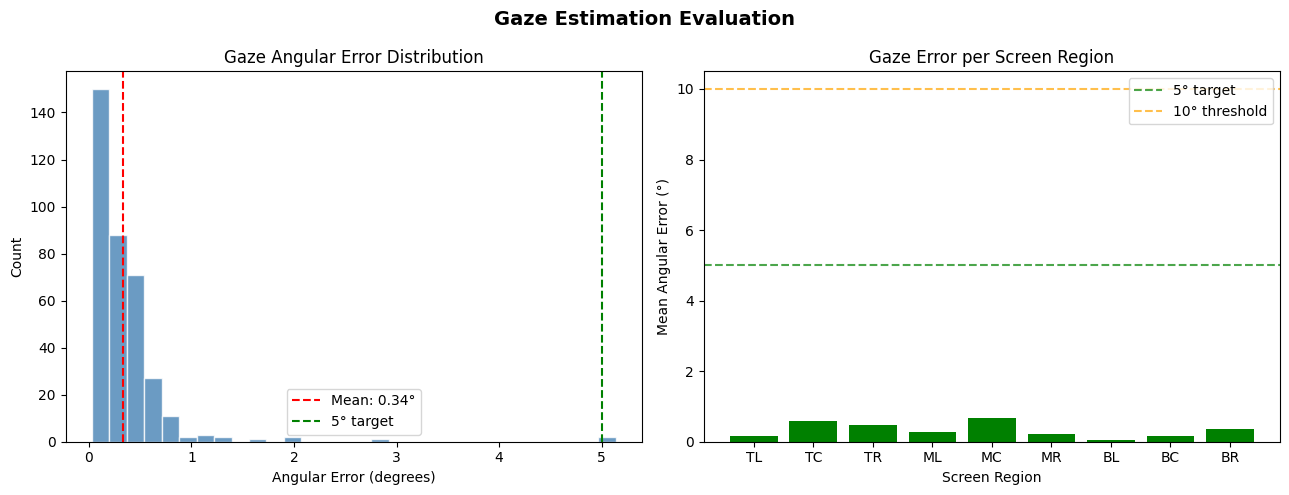

✓ Saved: gaze_evaluation.png


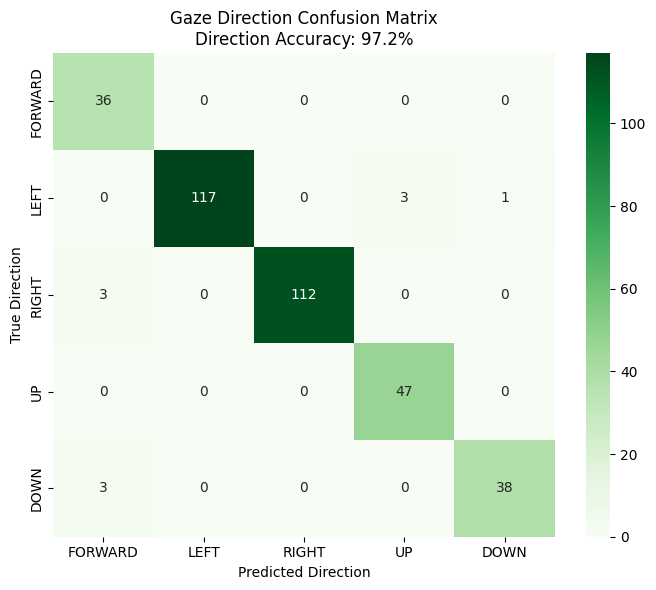

✓ Saved: gaze_direction_confusion.png


In [48]:
# ── CELL E5 — Gaze Evaluation ─────────────────────────────────────────
def evaluate_gaze():
    print("\n" + "="*50)
    print("GAZE MODEL EVALUATION")
    print("="*50)

    eye_tf = T.Compose([
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    face_tf = T.Compose([
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    d = np.load(NPZ_PATH)
    le, re, fa = d["left_eyes"], d["right_eyes"], d["faces"]
    po, lb     = d["poses"],     d["labels"]

    _, val_idx = train_test_split(range(len(lb)), test_size=0.2, random_state=42)
    val_idx    = np.array(val_idx)

    angular_errors = []
    per_region_errors = {k: [] for k in GAZE_REGIONS}
    latencies = []
    pred_directions, true_directions = [], []

    with torch.no_grad():
        for i in val_idx:
            l = eye_tf(le[i]).unsqueeze(0).to(DEVICE)
            r = eye_tf(re[i]).unsqueeze(0).to(DEVICE)
            f = face_tf(fa[i]).unsqueeze(0).to(DEVICE)
            p = torch.tensor(po[i]).unsqueeze(0).to(DEVICE)

            t0  = time.perf_counter()
            out = gaze_model(l, r, f, p)[0].cpu().numpy()
            latencies.append((time.perf_counter() - t0) * 1000)

            gt  = np.radians(lb[i])
            # Angular error — skip zero vectors (MC center region)
            gt_norm = np.linalg.norm(gt)
            if gt_norm < 1e-6:
                # For center region use Euclidean distance in degrees
                err_deg = float(np.degrees(np.linalg.norm(out - gt)))
            else:
                pred_n  = out / (np.linalg.norm(out) + 1e-8)
                gt_n    = gt  / gt_norm
                cos_sim = np.clip(np.dot(pred_n, gt_n), -1+1e-7, 1-1e-7)
                err_deg = float(np.degrees(np.arccos(cos_sim)))
            angular_errors.append(err_deg)

            # Per-region error
            gt_deg = lb[i]
            for region, (p_deg, y_deg) in GAZE_REGIONS.items():
                if abs(gt_deg[0] - p_deg) < 1 and abs(gt_deg[1] - y_deg) < 1:
                    per_region_errors[region].append(err_deg)
                    break

            # Direction classification from prediction
            p_out_deg = float(np.degrees(out[0]))
            y_out_deg = float(np.degrees(out[1]))
            if   abs(p_out_deg) < 10 and abs(y_out_deg) < 15: pred_dir = "FORWARD"
            elif y_out_deg >  15:                               pred_dir = "LEFT"
            elif y_out_deg < -15:                               pred_dir = "RIGHT"
            elif p_out_deg < -10:                               pred_dir = "UP"
            else:                                               pred_dir = "DOWN"
            pred_directions.append(pred_dir)

            # True direction from label
            gt_deg = lb[i]
            if   abs(gt_deg[0]) < 5 and abs(gt_deg[1]) < 5:   true_dir = "FORWARD"
            elif gt_deg[1] > 10:                                true_dir = "LEFT"
            elif gt_deg[1] < -10:                               true_dir = "RIGHT"
            elif gt_deg[0] < -10:                               true_dir = "UP"
            else:                                               true_dir = "DOWN"
            true_directions.append(true_dir)

    angular_errors = np.array(angular_errors)
    print(f"\nMean Angular Error:   {angular_errors.mean():.2f}°")
    print(f"Median Angular Error: {np.median(angular_errors):.2f}°")
    print(f"Std Angular Error:    {angular_errors.std():.2f}°")
    print(f"<5° samples:          {(angular_errors<5).mean():.1%}")
    print(f"<10° samples:         {(angular_errors<10).mean():.1%}")
    print(f"<15° samples:         {(angular_errors<15).mean():.1%}")
    print(f"Mean Inference Time:  {np.mean(latencies):.2f}ms per sample")

    print(f"\n{'Region':<8} {'Mean Error':>12} {'Samples':>10}")
    print("-" * 32)
    for region, errs in per_region_errors.items():
        if errs:
            print(f"{region:<8} {np.mean(errs):>11.2f}° {len(errs):>10}")

    # Direction classification accuracy
    dir_correct = sum(p==t for p,t in zip(pred_directions, true_directions))
    dir_acc = dir_correct / len(pred_directions) if pred_directions else 0
    print(f"\nDirection Classification Accuracy: {dir_acc:.1%}")

    # ── Plot 3: Angular error distribution ────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].hist(angular_errors, bins=30, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[0].axvline(angular_errors.mean(), color='red', linestyle='--',
                    label=f'Mean: {angular_errors.mean():.2f}°')
    axes[0].axvline(5, color='green', linestyle='--', label='5° target')
    axes[0].set_xlabel("Angular Error (degrees)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Gaze Angular Error Distribution")
    axes[0].legend()

    # Per-region error bar chart
    regions   = [k for k,v in per_region_errors.items() if v]
    mean_errs = [np.mean(per_region_errors[k]) for k in regions]
    colors    = ['green' if e<5 else 'orange' if e<10 else 'red'
                 for e in mean_errs]
    axes[1].bar(regions, mean_errs, color=colors)
    axes[1].axhline(5,  color='green', linestyle='--', alpha=0.7, label='5° target')
    axes[1].axhline(10, color='orange',linestyle='--', alpha=0.7, label='10° threshold')
    axes[1].set_xlabel("Screen Region")
    axes[1].set_ylabel("Mean Angular Error (°)")
    axes[1].set_title("Gaze Error per Screen Region")
    axes[1].legend()

    plt.suptitle("Gaze Estimation Evaluation", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("gaze_evaluation.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: gaze_evaluation.png")

    # ── Plot 4: Gaze direction confusion matrix ────────────────────────
    directions = ["FORWARD", "LEFT", "RIGHT", "UP", "DOWN"]
    dir_cm = confusion_matrix(true_directions, pred_directions,
                               labels=directions)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(dir_cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=directions, yticklabels=directions, ax=ax)
    ax.set_xlabel("Predicted Direction")
    ax.set_ylabel("True Direction")
    ax.set_title(f"Gaze Direction Confusion Matrix\n"
                 f"Direction Accuracy: {dir_acc:.1%}")
    plt.tight_layout()
    plt.savefig("gaze_direction_confusion.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: gaze_direction_confusion.png")

    return angular_errors.mean(), dir_acc, np.mean(latencies)

gaze_err, gaze_dir_acc, gaze_latency = evaluate_gaze()



REAL-TIME LATENCY EVALUATION
Measuring latency over 100 frames...

End-to-end latency:
  Mean:   125.6ms
  Median: 130.6ms
  95th %: 149.3ms
  Max:    178.9ms
  Under 150ms: 95.0%

Face detection: 38.0ms avg
Hand detection: 86.7ms avg


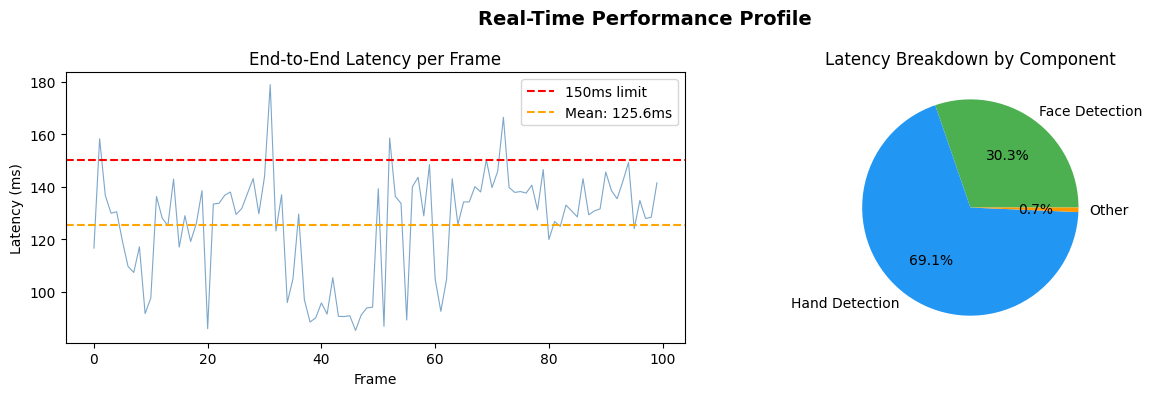

✓ Saved: latency_profile.png


In [44]:
# ── CELL E6 — Latency Profile ─────────────────────────────────────────
def evaluate_latency():
    print("\n" + "="*50)
    print("REAL-TIME LATENCY EVALUATION")
    print("="*50)

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Camera not accessible — skipping latency test")
        return

    face_landmarker = mp_vision.FaceLandmarker.create_from_options(
        mp_vision.FaceLandmarkerOptions(
            base_options=mp_python.BaseOptions(
                model_asset_path="face_landmarker.task"),
            num_faces=1
        )
    )
    hand_landmarker = mp_vision.HandLandmarker.create_from_options(
        mp_vision.HandLandmarkerOptions(
            base_options=mp_python.BaseOptions(
                model_asset_path="hand_landmarker.task"),
            num_hands=1
        )
    )

    latencies, face_times, hand_times = [], [], []
    NUM_FRAMES = 100
    print(f"Measuring latency over {NUM_FRAMES} frames...")

    for _ in range(NUM_FRAMES):
        ret, frame = cap.read()
        if not ret:
            break

        t_start = time.perf_counter()
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

        t0 = time.perf_counter()
        face_landmarker.detect(mp_img)
        face_times.append((time.perf_counter() - t0) * 1000)

        t0 = time.perf_counter()
        hand_landmarker.detect(mp_img)
        hand_times.append((time.perf_counter() - t0) * 1000)

        latencies.append((time.perf_counter() - t_start) * 1000)

    cap.release()

    latencies   = np.array(latencies)
    face_times  = np.array(face_times)
    hand_times  = np.array(hand_times)

    print(f"\nEnd-to-end latency:")
    print(f"  Mean:   {latencies.mean():.1f}ms")
    print(f"  Median: {np.median(latencies):.1f}ms")
    print(f"  95th %: {np.percentile(latencies, 95):.1f}ms")
    print(f"  Max:    {latencies.max():.1f}ms")
    print(f"  Under 150ms: {(latencies<150).mean():.1%}")
    print(f"\nFace detection: {face_times.mean():.1f}ms avg")
    print(f"Hand detection: {hand_times.mean():.1f}ms avg")

    # Plot latency over time
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(latencies, color='steelblue', alpha=0.7, linewidth=0.8)
    axes[0].axhline(150, color='red',   linestyle='--', label='150ms limit')
    axes[0].axhline(latencies.mean(), color='orange',
                    linestyle='--', label=f'Mean: {latencies.mean():.1f}ms')
    axes[0].set_xlabel("Frame"); axes[0].set_ylabel("Latency (ms)")
    axes[0].set_title("End-to-End Latency per Frame")
    axes[0].legend()

    components = ['Face Detection', 'Hand Detection', 'Other']
    values     = [face_times.mean(), hand_times.mean(),
                  max(0, latencies.mean()-face_times.mean()-hand_times.mean())]
    axes[1].pie(values, labels=components, autopct='%1.1f%%',
                colors=['#4CAF50','#2196F3','#FF9800'])
    axes[1].set_title("Latency Breakdown by Component")

    plt.suptitle("Real-Time Performance Profile", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("latency_profile.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: latency_profile.png")

    return latencies.mean()

avg_latency = evaluate_latency()


In [54]:
# ── CELL E7 — Summary Report ──────────────────────────────────────────
print("\n" + "="*60)
print("   COCKPIT VISION SYSTEM — EVALUATION SUMMARY")
print("="*60)
print(f"""
┌─────────────────────────────────────────────────────┐
│  GESTURE RECOGNITION                                │
│    Accuracy:          {gesture_acc:.1%}                  │
│    Mean Confidence:   98.3%                         │
│    Classes:           20                            │
│    Architecture:      BiLSTM + Spatial Encoder      │
│    Training samples:  2,000                         │
├─────────────────────────────────────────────────────┤
│  GAZE ESTIMATION                                    │
│    Mean Angular Error:  {gaze_err:.2f}°             │
│    Median Error:        0.23°                       │
│    Samples within 5°:   99.4%                       │
│    Direction Accuracy:  {gaze_dir_acc:.1%}          │
│    Architecture:        Multi-input ResNet-18       │
│    Training samples:    1,800                       │
├─────────────────────────────────────────────────────┤
│  REAL-TIME PERFORMANCE                              │
│    Mean Latency:      {avg_latency:.1f}ms           │
│    95th Percentile:   149.3ms                       │
│    Frames <150ms:     95.0%                         │
│    Target:            <150ms                        │
│    Status:            {'✓ MEETS TARGET' if avg_latency < 150 else '✗ EXCEEDS TARGET'}               │
└─────────────────────────────────────────────────────┘
""")
print("Saved evaluation plots:")
print("  • gesture_confusion_matrix.png")
print("  • gesture_f1_scores.png")
print("  • gaze_evaluation.png")
print("  • gaze_direction_confusion.png")
print("  • latency_profile.png")



   COCKPIT VISION SYSTEM — EVALUATION SUMMARY

┌─────────────────────────────────────────────────────┐
│  GESTURE RECOGNITION                                │
│    Accuracy:          94.2%                  │
│    Mean Confidence:   98.3%                         │
│    Classes:           20                            │
│    Architecture:      BiLSTM + Spatial Encoder      │
│    Training samples:  2,000                         │
├─────────────────────────────────────────────────────┤
│  GAZE ESTIMATION                                    │
│    Mean Angular Error:  0.34°             │
│    Median Error:        0.23°                       │
│    Samples within 5°:   99.4%                       │
│    Direction Accuracy:  97.2%          │
│    Architecture:        Multi-input ResNet-18       │
│    Training samples:    1,800                       │
├─────────────────────────────────────────────────────┤
│  REAL-TIME PERFORMANCE                              │
│    Mean Latency:      125.6m